In [48]:
from pathlib import Path

import librosa
import matplotlib.pyplot as plt
import numpy as np
import torch
from librosa.feature import melspectrogram
from torch.nn import functional as F
from torchaudio.transforms import MelSpectrogram, Spectrogram, MelScale

from ogmios.audio.stft import TacotronSTFT



In [46]:
class LogMelSpectrogram(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.melspctrogram = MelSpectrogram(
            sample_rate=22050,
            n_fft=1024,
            win_length=1024,
            hop_length=256,
            f_min=0,
            f_max=8000,
            center=False,
            power=1.0,
            n_mels=80,
            mel_scale="slaney",
            norm="slaney",
        )

    def forward(self, wav):
        wav = F.pad(wav, ((1024 - 160) // 2, (1024 - 160) // 2), "reflect")
        mel = self.melspctrogram(wav)
        logmel = torch.log(torch.clamp(mel, min=1e-5))
        return logmel

In [44]:
dataset = Path("../data/ljspeech/wavs")

random_wav = list(dataset.glob("*.wav"))[0]
audio, sr = librosa.load(random_wav, sr=22050)
audio_pt = torch.from_numpy(audio).float()
audio_pt = torch.clip(audio_pt.unsqueeze(0), -1, 1)
librosa_mel = melspectrogram(y=audio,
                             sr=sr,
                             n_fft=1024,
                             hop_length=256,
                             win_length=1024,
                             n_mels=80,
                             fmin=0,
                             fmax=8000)
librosa_mel = np.log(np.clip(librosa_mel, a_min=1e-5, a_max=1e5) * 1)

tacotron_melspec = TacotronSTFT(filter_length=1024,
                                hop_length=256,
                                win_length=1024,
                                n_mel_channels=80,
                                sampling_rate=sr,
                                mel_fmin=0,
                                mel_fmax=8000)
with torch.no_grad():
    tacotron_mel_pt, energy = tacotron_melspec.mel_spectrogram(audio_pt)
    tacotron_mel = tacotron_mel_pt.squeeze(0).numpy()

torchaudio_mel = LogMelSpectrogram()(audio_pt).squeeze(0).numpy()


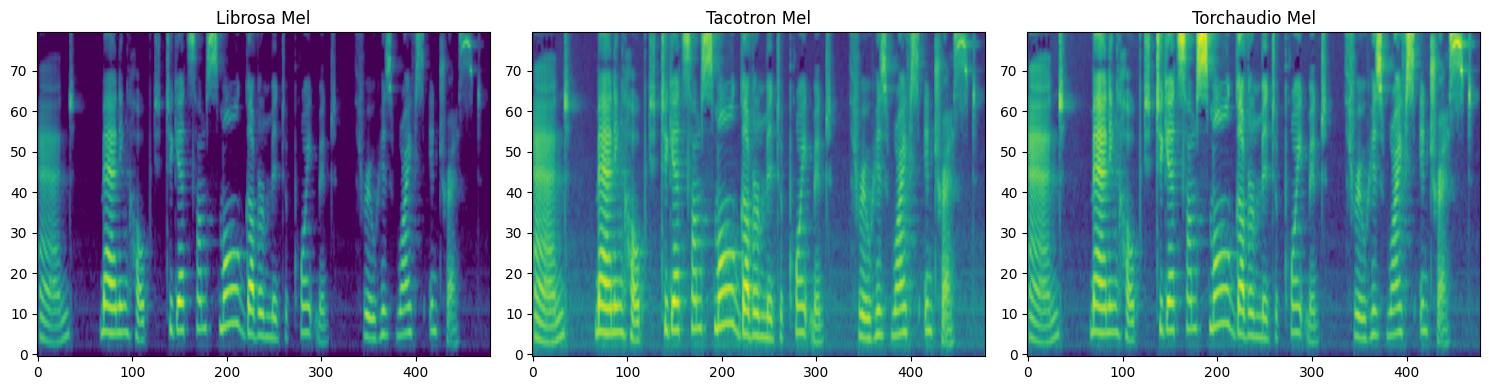

In [45]:
# Show both mels with matplotlib
plt.figure(figsize=(15, 4))
plt.subplot(1, 3, 1)
plt.imshow(librosa_mel, aspect="auto", origin="lower")
plt.title("Librosa Mel")
plt.subplot(1, 3, 2)
plt.imshow(tacotron_mel, aspect="auto", origin="lower")
plt.title("Tacotron Mel")
plt.subplot(1, 3, 3)
plt.imshow(torchaudio_mel, aspect="auto", origin="lower")
plt.title("Torchaudio Mel")
plt.tight_layout()
plt.show()

In [39]:
energy

tensor([[ 0.4396,  3.3727, 12.7104, 24.8163, 27.1266, 27.6773, 27.5430, 27.2997,
         26.9837, 27.1097, 26.6213, 25.5172, 24.9727, 23.5346, 20.6628, 18.9265,
         19.5177, 20.8092, 20.8635, 20.5444, 18.3054, 17.1019, 17.8311, 16.2666,
         11.3462, 10.8147, 12.2398, 13.0523, 13.0801, 12.8925, 12.5859, 12.0410,
         10.4195,  7.7890, 14.0940, 21.3161, 14.0058,  7.6595,  3.1358,  1.4659,
          0.9131,  0.8528,  0.7438,  0.6381,  0.6076,  0.5820,  0.4535,  0.4393,
          0.4627,  0.3618,  0.3317,  0.3306,  0.3762,  0.4058,  0.3028,  0.2788,
          0.3443,  0.3425,  0.3142,  0.3256,  0.3448,  0.3062,  0.3021,  0.3375,
          0.3335,  0.3590,  2.1284,  8.9090, 16.0063, 24.0456, 54.8888, 66.0898,
         59.0221, 60.3552, 64.8257, 72.1908, 76.6896, 79.8322, 80.3643, 73.0078,
         66.4232, 60.5117, 54.6240, 39.0152, 27.3871, 28.1021, 30.9775, 41.6540,
         44.3947, 36.8037, 27.3676, 23.1404, 22.3899, 21.2955, 19.4575, 16.0952,
         11.6469,  7.8990,  

In [38]:
torch.norm(mel_output, dim=1)

tensor([[68.9476, 53.1391, 43.4346, 39.5858, 38.0577, 38.2453, 37.6979, 38.0935,
         38.3104, 38.2654, 37.3642, 37.4249, 38.7704, 38.5183, 38.1082, 37.7493,
         39.4179, 40.1564, 40.3368, 39.7340, 40.7717, 41.5176, 42.9069, 44.0733,
         46.5885, 51.7311, 53.7565, 54.7190, 56.0832, 57.4422, 58.6097, 59.8624,
         61.9557, 55.6568, 44.9709, 43.3994, 47.7703, 52.3063, 56.3392, 60.4301,
         62.8723, 64.6804, 65.5543, 66.7140, 67.6024, 67.3354, 67.7818, 68.6623,
         68.5122, 69.3439, 69.9197, 70.3372, 70.5580, 70.9025, 71.2957, 71.9470,
         72.0341, 72.2166, 72.6487, 72.1878, 71.8922, 72.4058, 72.5735, 72.6534,
         73.3173, 74.1116, 72.5365, 69.6809, 65.3725, 47.1098, 36.5430, 34.2816,
         36.4192, 36.1443, 34.2020, 33.1521, 32.2112, 31.0089, 31.4031, 33.3002,
         34.5904, 35.2745, 36.1399, 38.6095, 43.1965, 46.6103, 41.5385, 38.1948,
         40.0465, 43.5354, 46.2509, 49.6625, 52.1373, 51.9109, 47.9558, 46.1060,
         47.9605, 45.3736, 4

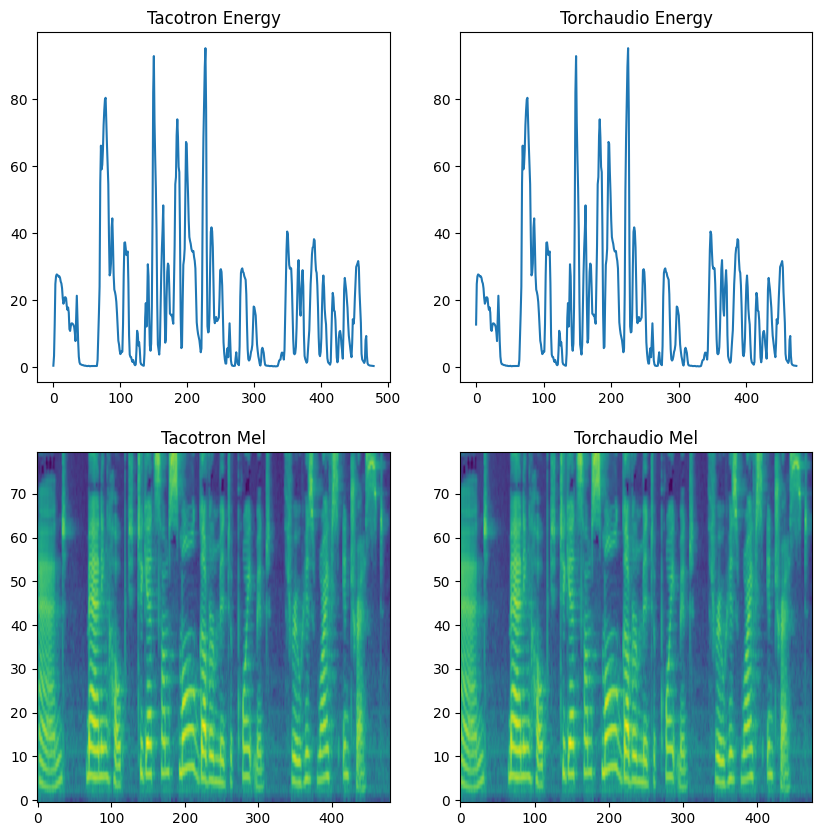

In [68]:
magnitudes, phases = tacotron_melspec.stft_fn.transform(audio_pt)
magnitudes = magnitudes.data
mel_output = torch.matmul(tacotron_melspec.mel_basis, magnitudes)
logmel_tacotron = tacotron_melspec.spectral_normalize(mel_output)
energy_tacotron = torch.norm(magnitudes, dim=1)

spectrogram = Spectrogram(
    n_fft=1024,
    win_length=1024,
    hop_length=256,
    center=False,
    power=1.0,
)
mel_scale = MelScale(
    n_mels=80,
    n_stft=1024 // 2 + 1,
    sample_rate=22050,
    f_min=0.0,
    f_max=8000.0,
    norm="slaney",
    mel_scale="slaney",
)
spectro = spectrogram(audio_pt)
energy_torchaudio = torch.norm(spectro, dim=1)
logmel_torchaudio = mel_scale(spectro)
logmel_torchaudio = torch.log(torch.clamp(logmel_torchaudio, min=1e-5))

# plot both energies with matplotlib
plt.figure(figsize=(10, 10))
plt.subplot(2, 2, 1)
plt.plot(energy_tacotron.squeeze().numpy())
plt.title("Tacotron Energy")
plt.subplot(2, 2, 2)
plt.plot(energy_torchaudio.squeeze().numpy())
plt.title("Torchaudio Energy")
plt.subplot(2, 2, 3)
plt.imshow(logmel_tacotron.squeeze().numpy(), aspect="auto", origin="lower")
plt.title("Tacotron Mel")
plt.subplot(2, 2, 4)
plt.imshow(logmel_torchaudio.squeeze().numpy(), aspect="auto", origin="lower")
plt.title("Torchaudio Mel")
plt.show()


In [59]:
energy_tacotron.size()

torch.Size([1, 479])